In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#generating an approximate linear didtribution

X = 2 * np.random.rand(100,1)
y = 4 + 3*X + np.random.randn(100,1) 

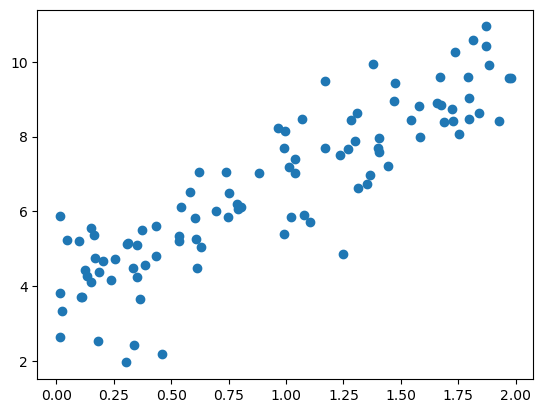

In [12]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(X,y)

### Computing theta using Normal Equation

In [13]:
X_b = np.c_[np.ones((100,1)), X] #adding x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [14]:
theta_best

array([[3.72592849],
       [3.0870347 ]])

In [15]:
# Lets generate some new data points 
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)), X_new] #adding x0 = 1 to each instance 

y_pred = X_new_b.dot(theta_best)
y_pred 

array([[3.72592849],
       [9.89999788]])

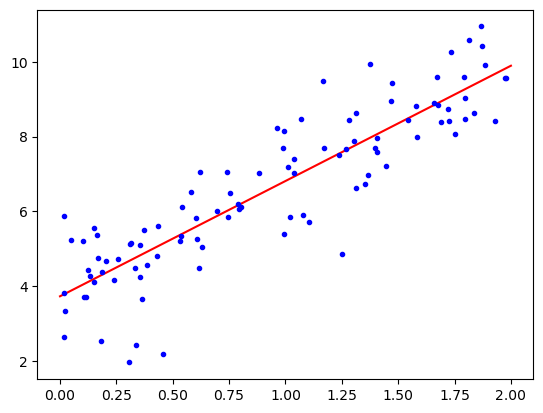

In [16]:
plt.plot(X_new, y_pred, "r-")
plt.plot(X,y,"b.")

### Performing Linear Regression using Scikit Learn

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lin_reg = LinearRegression()

In [21]:
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_

(array([3.72592849]), array([[3.0870347]]))

In [25]:
y_pred_sk = lin_reg.predict(X_new)
y_pred_sk

array([[3.72592849],
       [9.89999788]])

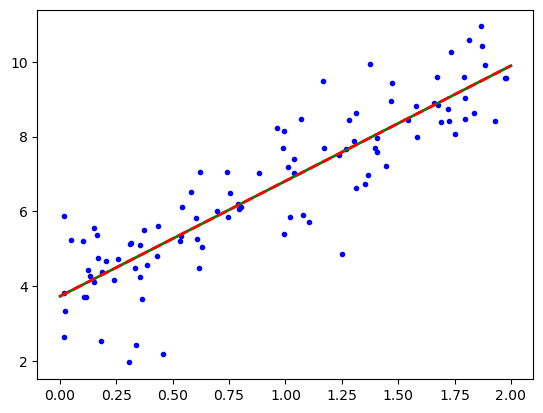

In [40]:
plt.plot(X,y,"b.")

plt.plot(X_new,y_pred_sk,"g-", linewidth = 2)
plt.plot(X_new, y_pred, "r--", linewidth = 2)

#the lines will overlap as both the solutions are very close

### Implementing Batch Gradient Descent

In [98]:
alpha = 0.1 
n = 100 #number of iterations
m = 100 

#random initialisation 
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))

In [99]:
theta

array([[ 0.30471708],
       [-1.03998411]])

### Gradient Descent Visualisations

In [115]:
def compute_cost(theta, X_b,y):
    return 1/(2*m) * np.sum((X_b.dot(theta) - y)**2)

In [116]:
theta_logs = [theta.copy()]
cost_logs = [compute_cost(theta,X_b,y)]

for i in range(n):
    gradients = 1/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - alpha * gradients
    theta_logs.append(theta)
    cost_logs.append(compute_cost(theta, X_b,y))

In [117]:
#final theta we got from gradient descent
theta

array([[3.72592849],
       [3.08703469]])

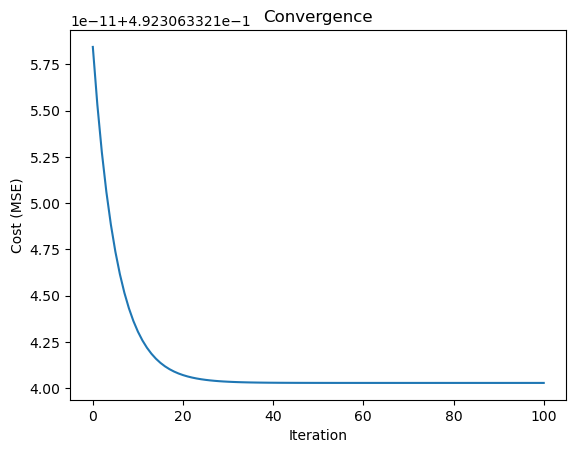

In [118]:
plt.plot(cost_logs)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Convergence")
plt.show()

In [119]:
#let's do the same for alpha - 0.02 

alpha = 0.02
n = 100 #number of iterations
m = 100 

#random initialisation 
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))
theta

array([[ 0.30471708],
       [-1.03998411]])

In [120]:
theta_logs_2 = [theta.copy()]
cost_logs_2 = [compute_cost(theta,X_b,y)]

for i in range(n):
    gradients = 1/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - alpha * gradients
    theta_logs_2.append(theta)
#     print(alpha)
    cost_logs_2.append(compute_cost(theta, X_b,y))

In [121]:
theta

array([[3.76159581],
       [2.94649834]])

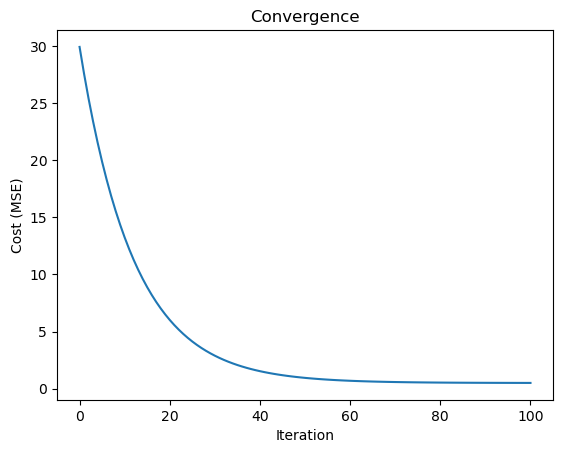

In [122]:
plt.plot(cost_logs_2)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Convergence")
plt.show()

In [147]:
#let's do the same for alpha - 0.5 

alpha = 0.9
n = 100 #number of iterations
m = 100 

#random initialisation 
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))
theta

array([[ 0.30471708],
       [-1.03998411]])

In [148]:
theta_logs_3 = [theta.copy()]
cost_logs_3 = [compute_cost(theta,X_b,y)]

for i in range(n):
    gradients = 1/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - alpha * gradients
    theta_logs_3.append(theta)
#     print(alpha)
    cost_logs_3.append(compute_cost(theta, X_b,y))

In [149]:
theta

array([[3.72592834],
       [3.08703452]])

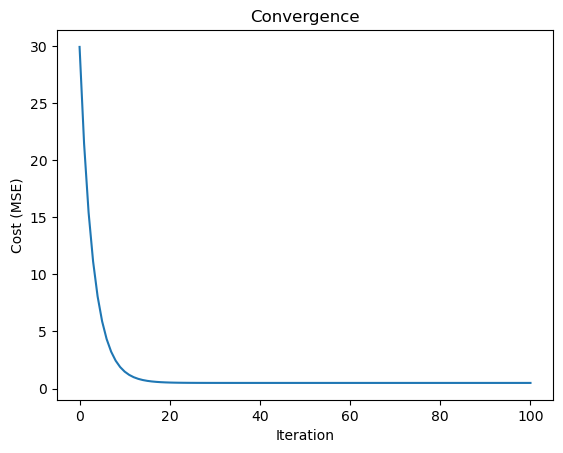

In [150]:
plt.plot(cost_logs_3)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Convergence")
plt.show()